In [1]:
# importing libraries 
import pandas as pd # for redaing csv files
import numpy as np # for mathematical operations
import matplotlib.pyplot as plt # for graphical visualization
import seaborn as sns # for statistical visualization

In [2]:
# loading dataset
df = pd.read_csv(r"C:\Users\rasika\Downloads\monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
# dataset summary
df.info()  # number of entries, number of columns and there data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
# Summary Statistics
df.describe() # count, mean, standard deviation, min, max, interquartiles of data in features of dataset

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


### Histogram to check data distribution of numerical feature

array([[<Axes: title={'center': 'Production'}>]], dtype=object)

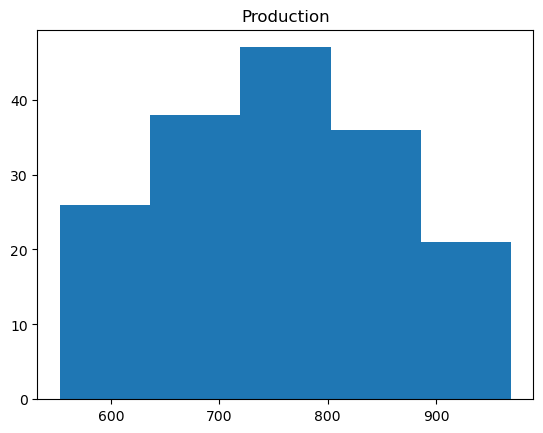

In [5]:
df.hist(bins = 5, grid = False)

##### Data is normally distributed in production as it is bell shape curved

### Boxplot for outlier detection

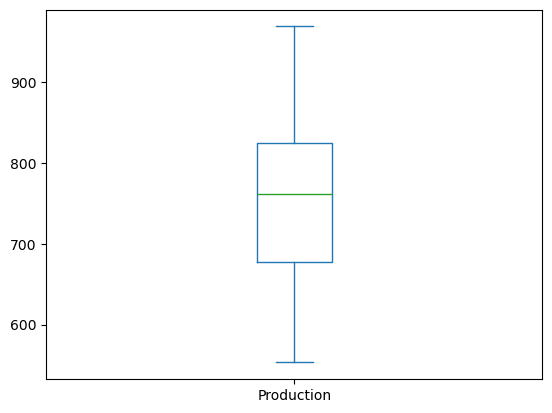

In [6]:
df['Production'].plot(kind = 'box')
plt.show()

##### No outliers in dataset

In [7]:
# Checking for missing values
df.isnull().sum()

Date          0
Production    0
dtype: int64

##### No missing or null values occur in dataset

In [8]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

##### No duplicates present 

In [9]:
# Converting date of object type to datetime type
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

0     1962-01-01
1     1962-02-01
2     1962-03-01
3     1962-04-01
4     1962-05-01
         ...    
163   1975-08-01
164   1975-09-01
165   1975-10-01
166   1975-11-01
167   1975-12-01
Name: Date, Length: 168, dtype: datetime64[ns]

In [10]:
# setting date as index to visualize milk production over date
df.set_index('Date', inplace = True)
df

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1975-08-01,858
1975-09-01,817
1975-10-01,827


### Milk Production over Date

Text(0, 0.5, 'Production')

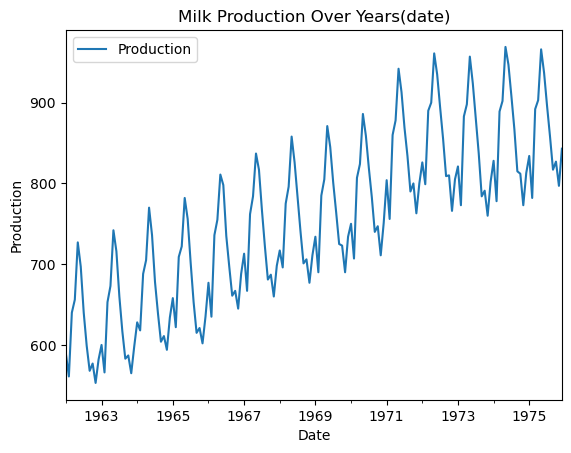

In [11]:
df.plot()
plt.title("Milk Production Over Years(date)")
plt.xlabel('Date')
plt.ylabel('Production')

In [12]:
# Feature scaling with minmax cause neural netwrok performs better with feature scaled between range of 0 to 1
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

X = df[['Production']]
X_mm = mm.fit_transform(X)

In [13]:
# Creating sequence 
window_size = 12

X = []
y = []

for i in range(window_size, len(X_mm)):
    X.append(X_mm[i-window_size:i])
    y.append(X_mm[i])

X = np.array(X)
y = np.array(y)

In [14]:
X

array([[[0.08653846],
        [0.01923077],
        [0.20913462],
        ...,
        [0.05769231],
        [0.        ],
        [0.06971154]],

       [[0.01923077],
        [0.20913462],
        [0.24759615],
        ...,
        [0.        ],
        [0.06971154],
        [0.11298077]],

       [[0.20913462],
        [0.24759615],
        [0.41826923],
        ...,
        [0.06971154],
        [0.11298077],
        [0.03125   ]],

       ...,

       [[0.62259615],
        [0.52884615],
        [0.625     ],
        ...,
        [0.82451923],
        [0.73317308],
        [0.63461538]],

       [[0.52884615],
        [0.625     ],
        [0.67548077],
        ...,
        [0.73317308],
        [0.63461538],
        [0.65865385]],

       [[0.625     ],
        [0.67548077],
        [0.55048077],
        ...,
        [0.63461538],
        [0.65865385],
        [0.58653846]]], shape=(156, 12, 1))

In [15]:
y

array([[0.11298077],
       [0.03125   ],
       [0.24038462],
       [0.28846154],
       [0.45432692],
       [0.39182692],
       [0.25721154],
       [0.15384615],
       [0.07211538],
       [0.08173077],
       [0.02884615],
       [0.10817308],
       [0.18028846],
       [0.15625   ],
       [0.32451923],
       [0.36538462],
       [0.52163462],
       [0.43990385],
       [0.30048077],
       [0.20673077],
       [0.12259615],
       [0.13942308],
       [0.09855769],
       [0.19471154],
       [0.25240385],
       [0.16586538],
       [0.375     ],
       [0.40625   ],
       [0.55048077],
       [0.48798077],
       [0.35817308],
       [0.24038462],
       [0.14903846],
       [0.16346154],
       [0.11778846],
       [0.19711538],
       [0.29807692],
       [0.19711538],
       [0.43990385],
       [0.48557692],
       [0.62019231],
       [0.58894231],
       [0.4375    ],
       [0.34615385],
       [0.25961538],
       [0.27403846],
       [0.22115385],
       [0.324

In [16]:
# Train-Test split, 80% data for training and 20%for testing
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [17]:
# checking input shape
X_train.shape

(124, 12, 1)

### Building RNN 

In [18]:
from tensorflow.keras.models import Sequential # creates neural network with layers stacked over 
from tensorflow.keras.layers import SimpleRNN # model building
from tensorflow.keras.layers import Dense # creates fully connected layers 

rnn = Sequential() # creates empty neural network
rnn.add(SimpleRNN(50, activation = 'tanh', input_shape = (12, 1))) # creates hidden layer with 50 neurons
rnn.add(Dense(1)) # creates one output layer

rnn.compile(optimizer = 'adam', loss = 'mse') # parameters controls errors and weights, tells how wrong predictions are.

# Training model with epochs, batch size
history_rnn = rnn.fit(X_train, y_train, epochs = 100, batch_size = 14, validation_split = 0.2, verbose = 0)

C:\Users\rasika\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Building LSTM 

In [19]:
from tensorflow.keras.layers import LSTM # building neural network with LSTM model 

lstm = Sequential()  # creates empty neural network
lstm.add(LSTM(50, activation = 'tanh', input_shape = (12, 1))) # creates hidden layer with 50 neurons
lstm.add(Dense(1)) # creates one output layer

lstm.compile(optimizer='adam', loss='mse') # parameters controls errors and weights, tells how wrong predictions are.

# Training model with epochs, batch size
history_lstm = lstm.fit( X_train, y_train, epochs=100, batch_size=14, validation_split=0.2, verbose = 0)

C:\Users\rasika\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Building GRU

In [20]:
from tensorflow.keras.layers import GRU # building neural network with GRU model 

gru = Sequential()  # creates empty neural network
gru.add(GRU(50, activation='tanh', input_shape=(12,1))) # creates hidden layer with 50 neurons.
gru.add(Dense(1))

gru.compile(optimizer='adam', loss='mse') # parameters controls errors and weights, tells how wrong predictions are.

# Training model with epochs, batch size
history_gru = gru.fit( X_train, y_train, epochs=100, batch_size=14, validation_split=0.2, verbose = 0)

C:\Users\rasika\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Prediction

In [43]:
rnn_pred_scaled = rnn.predict(X_test)
lstm_pred_scaled = lstm.predict(X_test)
gru_pred_scaled = gru.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


In [44]:
# converting back to original values  cause after prediction we will get values in decimal with which we will not be able to understand product valu so will will convert it to original form
rnn_pred = mm.inverse_transform(rnn_pred_scaled)
lstm_pred = mm.inverse_transform(lstm_pred_scaled)
gru_pred = mm.inverse_transform(gru_pred_scaled)
y_test_actual = mm.inverse_transform(y_test)

### Evaluation Metrics

For RNN

In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae_rnn = mean_absolute_error(y_test_actual, rnn_pred)
rmse_rnn = np.sqrt(mean_squared_error(y_test_actual,rnn_pred))
mape_rnn = np.mean(np.abs((y_test_actual-rnn_pred)/y_test_actual))*100

print(np.round(mae_rnn, 2))
print(np.round(rmse_rnn, 2))
print(np.round(mape_rnn, 2))

13.48
16.59
1.58


For LSTM

In [48]:
mae_lstm = mean_absolute_error(y_test_actual, lstm_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual,lstm_pred))
mape_lstm = np.mean(np.abs((y_test_actual-lstm_pred)/y_test_actual))*100

print(np.round(mae_lstm, 2))
print(np.round(rmse_lstm, 2))
print(np.round(mape_lstm, 2))

26.06
30.96
3.01


For GRU

In [50]:
mae_gru = mean_absolute_error(y_test_actual, gru_pred)
rmse_gru = np.sqrt(mean_squared_error(y_test_actual,gru_pred))
mape_gru = np.mean(np.abs((y_test_actual-gru_pred)/y_test_actual))*100

print(np.round(mae_gru, 2))
print(np.round(rmse_gru, 2))
print(np.round(mape_gru, 2))

26.42
39.02
3.2


### Plot of Actual vs Predicted values 

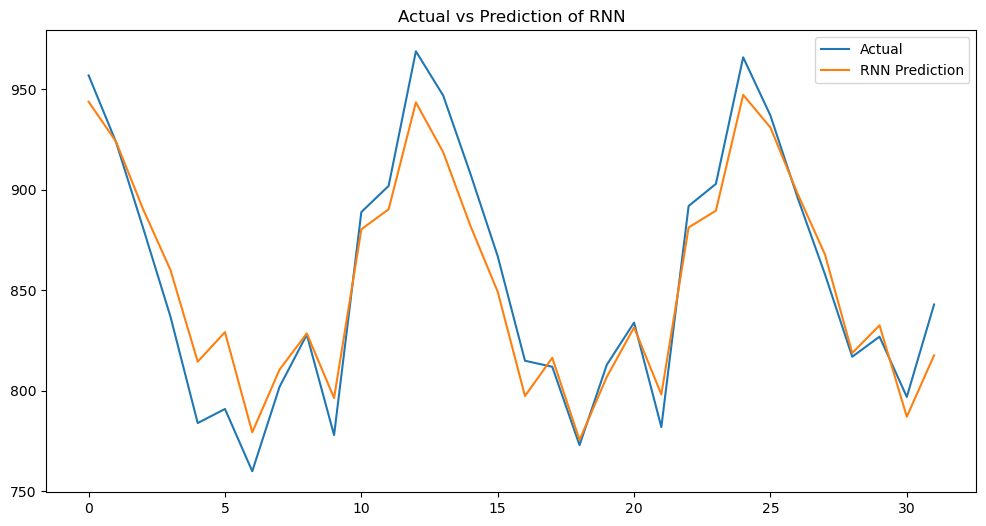

In [66]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(rnn_pred, label='RNN Prediction')
plt.title("Actual vs Prediction of RNN")
plt.legend()
plt.show()

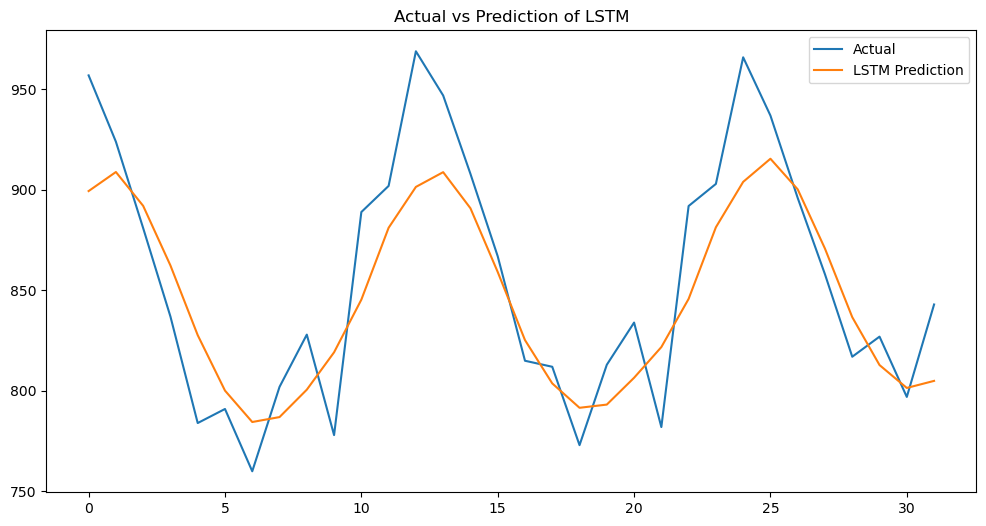

In [67]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(lstm_pred, label='LSTM Prediction')
plt.title("Actual vs Prediction of LSTM")
plt.legend()
plt.show()

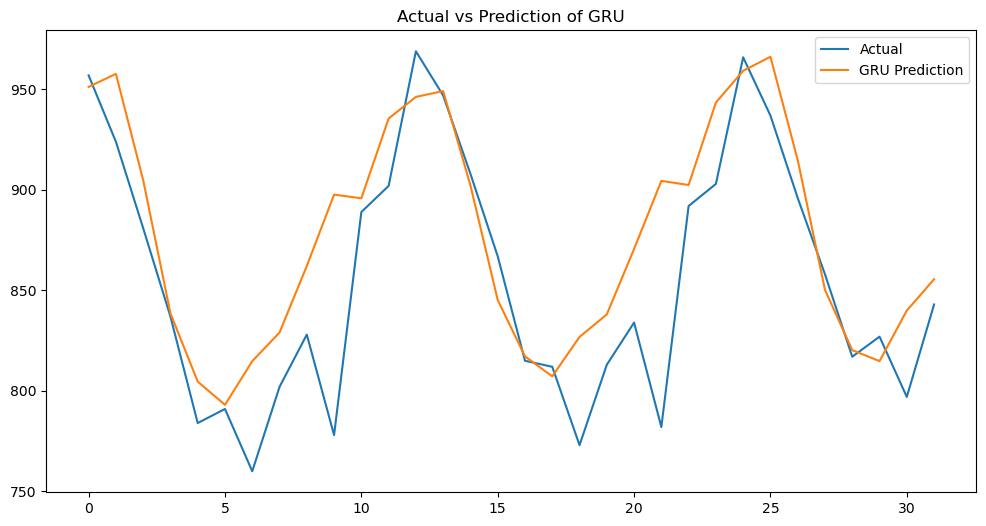

In [68]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(gru_pred, label='GRU Prediction')
plt.title("Actual vs Prediction of GRU")
plt.legend()
plt.show()

### Forecasting next 12 months

In [81]:
# for RNN
future_steps_rnn = 12
last_window_rnn = X_mm[-12:]
future_predictions_rnn = []
for i in range(future_steps_rnn):
    pred_rnn = rnn.predict(last_window_rnn.reshape(1,12,1))
    future_predictions_rnn.append(pred_rnn[0][0])
    last_window_rnn = np.append(last_window_rnn[1:],pred_rnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


In [82]:
# for LSTM
future_steps_lstm = 12
last_window_lstm = X_mm[-12:]
future_predictions_lstm = []
for i in range(future_steps_lstm):
    pred_lstm = lstm.predict(last_window_lstm.reshape(1,12,1))
    future_predictions_lstm.append(pred_lstm[0][0])
    last_window_lstm = np.append(last_window_lstm[1:],pred_lstm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


In [83]:
# for LSTM
future_steps_gru = 12
last_window_gru = X_mm[-12:]
future_predictions_gru = []
for i in range(future_steps_gru):
    pred_gru = gru.predict(last_window_gru.reshape(1,12,1))
    future_predictions_gru.append(pred_gru[0][0])
    last_window_gru = np.append(last_window_gru[1:],pred_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


In [84]:
future_predictions_rnn = np.array(future_predictions_rnn).reshape(-1,1)
future_predictions_rnn = mm.inverse_transform(future_predictions_rnn)

In [87]:
future_predictions_lstm = np.array(future_predictions_lstm).reshape(-1,1)
future_predictions_lstm = mm.inverse_transform(future_predictions_lstm)

In [88]:
future_predictions_gru = np.array(future_predictions_gru).reshape(-1,1)
future_predictions_gru = mm.inverse_transform(future_predictions_gru)

### PLoting Forecast

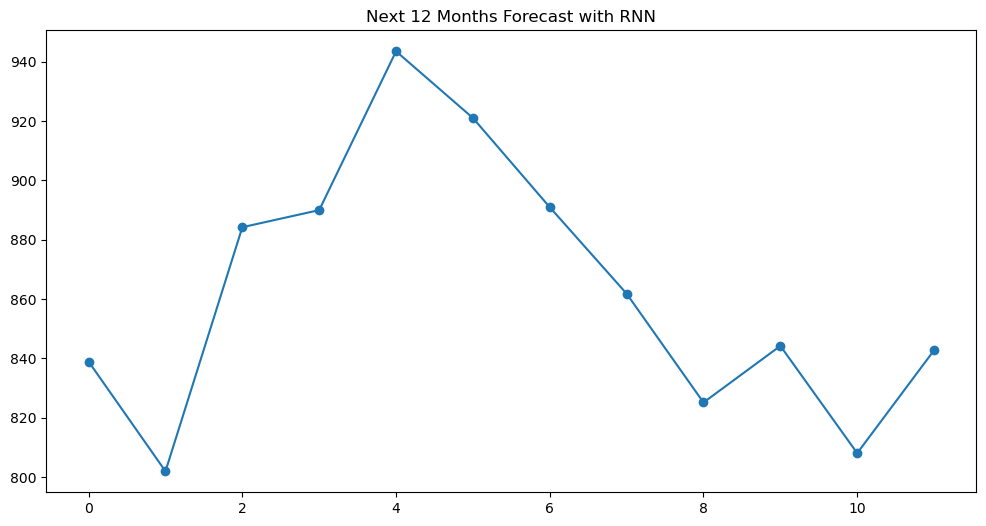

In [89]:
plt.figure(figsize = (12, 6))
plt.plot(future_predictions_rnn, marker = 'o')
plt.title("Next 12 Months Forecast with RNN")
plt.show()

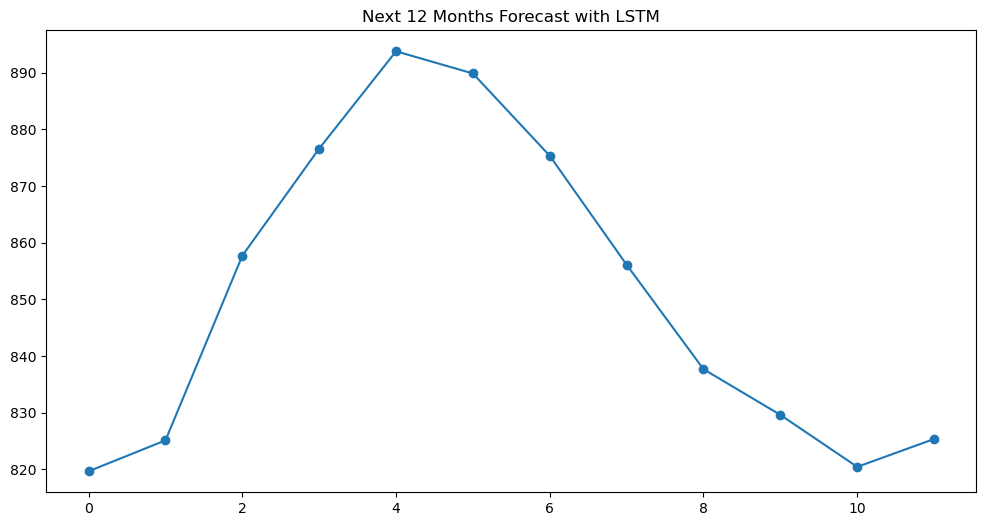

In [90]:
plt.figure(figsize = (12, 6))
plt.plot(future_predictions_lstm, marker = 'o')
plt.title("Next 12 Months Forecast with LSTM")
plt.show()

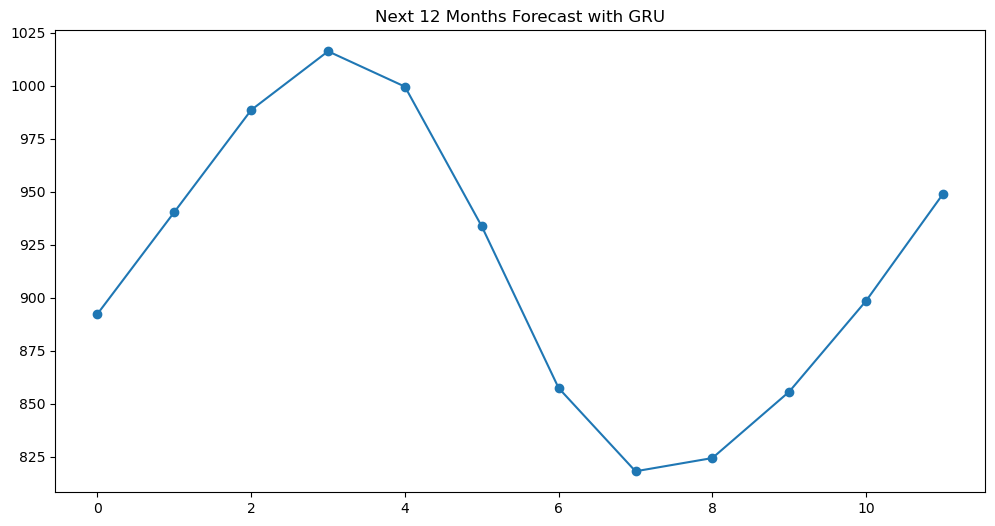

In [92]:
plt.figure(figsize = (12, 6))
plt.plot(future_predictions_gru, marker = 'o')
plt.title("Next 12 Months Forecast with GRU")
plt.show()

No  hyper parameter done for models cause parameter tunning is sensitive so it does not give output as early require so initially tried with best parameters

### Interpreatation and Analysis

1. No missing values.
2. No duplicate records.
3. No significant outliers.
4. A clear seasonal pattern in milk production over the years.

The Simple RNN model performed best among all three models because it achieved the lowest MAE, RMSE, and MAPE values. This indicates that the RNN predictions were closest to the actual milk production values and had the smallest forecasting error.

Lowest MAE (13.48), Lowest RMSE (16.59), Lowest MAPE (1.58%), from figure Predictions closely followed actual production values.

Business Insights: 

Since the RNN model provides the most accurate forecasts, the dairy business can use its predictions to:
1. Plan inventory and cold storage requirements in advance.
2. Optimize transportation and distribution schedules.
3. Allocate workforce efficiently during high and low production periods.
4. Prepare for seasonal fluctuations in milk production.

The forecasts indicate that milk production will not remain constant throughout the year. Instead, production is expected to experience seasonal increases and decreases, consistent with historical trends. This seasonal behavior is common in dairy production due to factors such as weather conditions, feed availability, and livestock productivity cycles.

Since the RNN model achieved the lowest RMSE (16.59), MAE (13.48), and MAPE (1.58%), its forecast is considered the most reliable among the three models. Therefore, the RNN forecast should be used for business planning.